<a href="https://colab.research.google.com/github/sunitha7780/23B91A1298/blob/main/dl_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np

from tensorflow.keras import layers



# Paths
DATASET_PATH = "/content/drive/MyDrive/prawn_dataset_images_only"
MODEL_SAVE_PATH = "/content/drive/MyDrive/prawn_disease_model_final.keras"

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

# Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# HARD-SET CLASS ORDER (CRITICAL FIX)
class_names = ['BG', 'BG-WSSV', 'WSSV']
print("Class names:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/prawn_dataset_images_only'

In [ ]:
import os
from tensorflow.keras import layers

# Mount Drive
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def preprocess(img, label):
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Transfer learning

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(3, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/25
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6754 - loss: 0.7028

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Input is empty.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
	 [[IteratorGetNext/_4]]
  (1) INVALID_ARGUMENT:  Input is empty.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]]
0 successful operations.
0 derived errors ignored. [Op:__inference_multi_step_on_iterator_16412]

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


NameError: name 'base_model' is not defined

In [ ]:
model.save(MODEL_SAVE_PATH)
print("✅ Final model saved to:", MODEL_SAVE_PATH)


✅ Final model saved to: /content/drive/MyDrive/prawn_disease_model_final.keras


In [ ]:
import os
import random
from PIL import Image
import numpy as np

def predict_image_colab(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    preds = model.predict(img_array)[0]

    print("\nTesting image:", img_path)
    for name, score in zip(class_names, preds):
        print(f"{name}: {score:.4f}")

    idx = np.argmax(preds)
    print("Predicted:", class_names[idx])


# -------- AUTO PICK 1 IMAGE FROM EACH CLASS --------

base_path = "/content/drive/MyDrive/prawn_dataset_images_only"

for cls in class_names:
    cls_folder = os.path.join(base_path, cls)
    files = os.listdir(cls_folder)
    img_file = random.choice(files)
    img_path = os.path.join(cls_folder, img_file)

    predict_image_colab(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Testing image: /content/drive/MyDrive/prawn_dataset_images_only/BG/BG-42-img-3_aug_0.jpg
BG: 0.9998
BG-WSSV: 0.0002
WSSV: 0.0000
Predicted: BG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Testing image: /content/drive/MyDrive/prawn_dataset_images_only/BG-WSSV/WSSV_BG-7-img-1_aug_3.jpg
BG: 0.0000
BG-WSSV: 1.0000
WSSV: 0.0000
Predicted: BG-WSSV
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Testing image: /content/drive/MyDrive/prawn_dataset_images_only/WSSV/WSSV-67-img-2_aug_0.jpg
BG: 0.0052
BG-WSSV: 0.0770
WSSV: 0.9178
Predicted: WSSV


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving wssv1.jpg to wssv1.jpg


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    predicted_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("✅ Collected predictions for validation set")


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is empty.
	 [[{{node decode_image/DecodeImage}}]] [Op:IteratorGetNext] name: 

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Prawn Disease Classification")
plt.show()


Confusion Matrix:
 []


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 600x500 with 0 Axes>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")

print("📊 Model Performance Metrics\n")
print("Accuracy : ", round(accuracy * 100, 2), "%")
print("Precision: ", round(precision * 100, 2), "%")
print("Recall   : ", round(recall * 100, 2), "%")
print("F1 Score : ", round(f1 * 100, 2), "%")


📊 Model Performance Metrics

Accuracy :  nan %
Precision:  nan %
Recall   :  nan %
F1 Score :  nan %


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
from sklearn.metrics import classification_report

print("\n📄 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



📄 Classification Report:

              precision    recall  f1-score   support

          BG       1.00      0.80      0.89        25
     BG-WSSV       0.71      1.00      0.83        20
        WSSV       1.00      0.84      0.91        19

    accuracy                           0.88        64
   macro avg       0.90      0.88      0.88        64
weighted avg       0.91      0.88      0.88        64



GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['BG', 'WSSV', 'BG-WSSV']
✅ Images copied into clean class folders.
Found 321 files belonging to 3 classes.
Using 257 files for training.
Found 321 files belonging to 3 classes.
Using 64 files for validation.
Class labels: ['BG', 'BG-WSSV', 'WSSV']


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 772ms/step - accuracy: 0.9884 - loss: 0.0299 - val_accuracy: 0.9688 - val_loss: 0.0833
Epoch 27/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9814 - loss: 0.0469

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 900ms/step - accuracy: 0.9813 - loss: 0.0460 - val_accuracy: 0.9844 - val_loss: 0.0779
Epoch 28/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.9973 - loss: 0.0172

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 765ms/step - accuracy: 0.9962 - loss: 0.0195 - val_accuracy: 0.9844 - val_loss: 0.0664
Epoch 29/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.9970 - loss: 0.0153

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 932ms/step - accuracy: 0.9961 - loss: 0.0162 - val_accuracy: 0.9844 - val_loss: 0.0672
Epoch 30/30
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9965 - loss: 0.0118

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 903ms/step - accuracy: 0.9948 - loss: 0.0131 - val_accuracy: 0.9531 - val_loss: 0.0893
✅ Final model saved at: /content/drive/MyDrive/prawn_disease_model_final.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


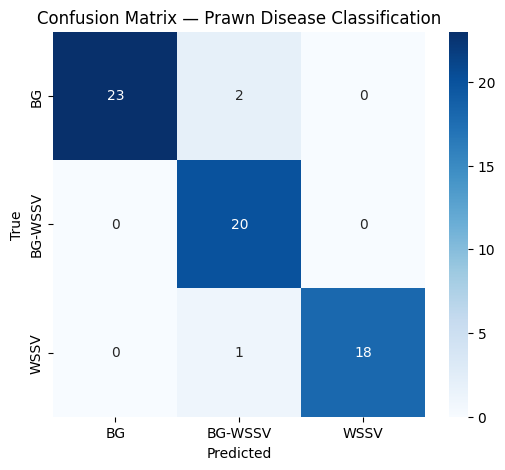


📊 Performance Metrics
Accuracy :  95.31 %
Precision:  95.92 %
Recall   :  95.31 %
F1 Score :  95.39 %

📄 Classification Report:

              precision    recall  f1-score   support

          BG       1.00      0.92      0.96        25
     BG-WSSV       0.87      1.00      0.93        20
        WSSV       1.00      0.95      0.97        19

    accuracy                           0.95        64
   macro avg       0.96      0.96      0.95        64
weighted avg       0.96      0.95      0.95        64



KeyboardInterrupt: 

In [ ]:
# ============================
# PRawn Disease Classification — FULL COLAB PIPELINE
# ============================

# --- STEP 1: Enable GPU ---
import tensorflow as tf
print("GPU Devices:", tf.config.list_physical_devices("GPU"))

# --- STEP 2: Mount Drive ---
from google.colab import drive
drive.mount("/content/drive")

# --- STEP 3: Paths ---
import os, shutil

ORIGINAL_DATASET = "/content/drive/MyDrive/latestdataset/augmented_dataset"
TEMP_DATASET     = "/content/drive/MyDrive/prawn_dataset_images_only"
CHECKPOINT_DIR   = "/content/drive/MyDrive/prawn_checkpoints"

os.makedirs(TEMP_DATASET, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Classes:", os.listdir(ORIGINAL_DATASET))

# --- STEP 4: Copy images into clean class folders ---
classes = os.listdir(ORIGINAL_DATASET)

for cls in classes:
    src_img_dir = os.path.join(ORIGINAL_DATASET, cls, "image")
    dst_cls_dir = os.path.join(TEMP_DATASET, cls)
    os.makedirs(dst_cls_dir, exist_ok=True)

    for fname in os.listdir(src_img_dir):
        src_file = os.path.join(src_img_dir, fname)
        dst_file = os.path.join(dst_cls_dir, fname)
        if os.path.isfile(src_file):
            shutil.copy(src_file, dst_file)

print("✅ Images copied into clean class folders.")

# --- STEP 5: Load datasets ---
IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEMP_DATASET,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEMP_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class labels:", class_names)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# --- STEP 6: Data augmentation + MobileNetV2 model ---
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# --- STEP 7: Checkpoint callback ---
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "model_epoch_{epoch:02d}.h5"),
    save_weights_only=False,
    save_best_only=False
)

# --- STEP 8: Train model ---
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb]
)

# --- STEP 9: Save final model (.keras for deployment) ---
FINAL_MODEL_PATH = "/content/drive/MyDrive/prawn_disease_model_final.keras"
model.save(FINAL_MODEL_PATH)
print("✅ Final model saved at:", FINAL_MODEL_PATH)

# --- STEP 10: Confusion matrix + metrics ---
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Prawn Disease Classification")
plt.show()

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")

print("\n📊 Performance Metrics")
print("Accuracy : ", round(accuracy * 100, 2), "%")
print("Precision: ", round(precision * 100, 2), "%")
print("Recall   : ", round(recall * 100, 2), "%")
print("F1 Score : ", round(f1 * 100, 2), "%")

print("\n📄 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- STEP 11: Upload your own image for testing ---
from google.colab import files
uploaded = files.upload()

# --- STEP 12: Predict uploaded image ---
from PIL import Image

img_path = list(uploaded.keys())[0]
print("Testing image:", img_path)

def predict_image_colab(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    preds = model.predict(img_array)[0]

    print("\nClass Probabilities:")
    for name, score in zip(class_names, preds):
        print(f"{name}: {score:.4f}")

    idx = np.argmax(preds)
    confidence = preds[idx]

    print("\n✅ Predicted Disease:", class_names[idx])
    print("📊 Confidence:", round(confidence * 100, 2), "%")

predict_image_colab(img_path)


In [ ]:
import tensorflow as tf

# Load trained model from Drive
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/prawn_disease_model_final.keras"
)

# Hard-set class order (CRITICAL)
class_names = ['BG', 'BG-WSSV', 'WSSV']

print("✅ Model loaded successfully")
model.summary()


✅ Model loaded successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,124,363 (23.36 MB)

 Trainable params: 1,848,451 (7.05 MB)

 Non-trainable params: 579,008 (2.21 MB)

 Optimizer params: 3,696,904 (14.10 MB)

In [ ]:
from google.colab import files

uploaded = files.upload()


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image

# Get uploaded file name dynamically
img_path = list(uploaded.keys())[0]
print("Testing image:", img_path)

def predict_image_colab(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    preds = model.predict(img_array)[0]

    print("\nClass Probabilities:")
    for name, score in zip(class_names, preds):
        print(f"{name}: {score:.4f}")

    idx = np.argmax(preds)
    confidence = preds[idx]

    print("\n✅ Predicted Disease:", class_names[idx])
    print("📊 Confidence:", round(confidence * 100, 2), "%")

predict_image_colab(img_path)


Testing image: wssv2 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Class Probabilities:
BG: 0.4026
BG-WSSV: 0.3639
WSSV: 0.2335

✅ Predicted Disease: BG
📊 Confidence: 40.26 %


In [ ]:
# ============================
# PRawn Disease Classification — FULL COLAB PIPELINE
# ============================

# --- STEP 1: Enable GPU ---
import tensorflow as tf
print("GPU Devices:", tf.config.list_physical_devices("GPU"))

# --- STEP 2: Mount Drive ---
from google.colab import drive
drive.mount("/content/drive")

# --- STEP 3: Paths ---
import os, shutil

ORIGINAL_DATASET = "/content/drive/MyDrive/latestdataset/augmented_dataset"
TEMP_DATASET     = "/content/drive/MyDrive/prawn_dataset_images_only"
CHECKPOINT_DIR   = "/content/drive/MyDrive/prawn_checkpoints"

os.makedirs(TEMP_DATASET, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Classes:", os.listdir(ORIGINAL_DATASET))

# --- STEP 4: Copy images into clean class folders ---
classes = os.listdir(ORIGINAL_DATASET)

for cls in classes:
    src_img_dir = os.path.join(ORIGINAL_DATASET, cls, "image")
    dst_cls_dir = os.path.join(TEMP_DATASET, cls)
    os.makedirs(dst_cls_dir, exist_ok=True)

    for fname in os.listdir(src_img_dir):
        src_file = os.path.join(src_img_dir, fname)
        dst_file = os.path.join(dst_cls_dir, fname)
        if os.path.isfile(src_file):
            shutil.copy(src_file, dst_file)

print("✅ Images copied into clean class folders.")

# --- STEP 5: Load datasets ---
IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEMP_DATASET,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEMP_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class labels:", class_names)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# --- STEP 6: Data augmentation + MobileNetV2 model ---
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# --- STEP 7: Checkpoint callback ---
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "model_epoch_{epoch:02d}.h5"),
    save_weights_only=False,
    save_best_only=False
)

# --- STEP 8: Train model ---
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb]
)

# --- STEP 9: Save final model (.keras for deployment) ---
FINAL_MODEL_PATH = "/content/drive/MyDrive/prawn_disease_model_final.keras"
model.save(FINAL_MODEL_PATH)
print("✅ Final model saved at:", FINAL_MODEL_PATH)

# --- STEP 10: Confusion matrix + metrics ---
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Prawn Disease Classification")
plt.show()

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")

print("\n📊 Performance Metrics")
print("Accuracy : ", round(accuracy * 100, 2), "%")
print("Precision: ", round(precision * 100, 2), "%")
print("Recall   : ", round(recall * 100, 2), "%")
print("F1 Score : ", round(f1 * 100, 2), "%")

print("\n📄 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- STEP 11: Upload your own image for testing ---
from google.colab import files
uploaded = files.upload()

# --- STEP 12: Predict uploaded image ---
from PIL import Image

img_path = list(uploaded.keys())[0]
print("Testing image:", img_path)

def predict_image_colab(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    preds = model.predict(img_array)[0]

    print("\nClass Probabilities:")
    for name, score in zip(class_names, preds):
        print(f"{name}: {score:.4f}")

    idx = np.argmax(preds)
    confidence = preds[idx]

    print("\n✅ Predicted Disease:", class_names[idx])
    print("📊 Confidence:", round(confidence * 100, 2), "%")

predict_image_colab(img_path)
